# Counting: Sample the Field at Random Positions

This notebook shows how PyHermes turns a saved `ConvolsData` field into a one-point sampling dataset. The main idea is simple: optionally smooth the field, evaluate it at many random positions, and study the resulting distribution.

## What this notebook emphasizes

- the standard task interfaces for `Counting`
- how `ConvolsData` and `WindowFunc` are passed into the task
- how the sampled values can be used to inspect the PDF of a smoothed field


In [1]:
from pyhermes.theory.counting import Counting
from pyhermes.param.parambase import read_param
from pyhermes.utils.sampling import random_points_box
from pyhermes.io import WindowFunc, ConvolsData, CountingData
import matplotlib.pyplot as plt

from pathlib import Path
import os
os.chdir(Path.cwd().resolve().parent)
print(f"Working directory: {Path.cwd()}")

Working directory: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


## 1. Standard `Counting` workflows

All workflows below do the same conceptual job: draw random points in the box and evaluate either the raw field or a smoothed version of it at those positions.


### Command-line entry point

Use the standard driver when you want the cleanest path from config file to saved output.


In [2]:
! python ./scripts/run_counting.py ./configs/param_counting.yaml

16:11:36 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_counting.yaml'
16:11:36 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
16:11:36 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
16:11:36 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
16:11:36 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.random_count' from '1000000' to '10000000'
16:11:36 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.window.type' from 'empty' to 'sphere'
16:11:36 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Counting.window.len_args.R'
16:11:36 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.threads' from '1' to '8'
16:11:36 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.fout_path' from 'empty' to './output/quijote80

### Config-driven Python API

This keeps the YAML config in control while making the resulting `CountingData` object immediately available in the notebook.


In [3]:
counting_params = read_param('./configs/param_counting.yaml')
task = Counting(param_task=counting_params)
task.run(overwrite=True)

16:11:39 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_counting.yaml'
16:11:39 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
16:11:39 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
16:11:39 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
16:11:39 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.random_count' from '1000000' to '10000000'
16:11:39 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.window.type' from 'empty' to 'sphere'
16:11:39 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Counting.window.len_args.R'
16:11:39 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.threads' from '1' to '8'
16:11:39 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.fout_path' from 'empty' to './output/quijote80

### Task object overrides

This version creates the task first and then adjusts a few attributes in Python. It is useful when you want to change the sample count, smoothing window, or threading without editing the config file.


In [4]:
task = Counting()
task.threads = 8
task.random_count = 1000000
task.convols_data = './output/quijote8000_snap004_sfc_massweight.pkl'
task.window = {"type": "sphere", "len_args": {"R": 20}}
counting_massw = task.run(save_result=False)

16:11:42 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...

16:11:42 - INFO - pyhermes.pipeline.pipeline:Counting - Counting runtime configuration: running on 1 MPI ranks with 8 threads per rank
16:11:42 - INFO - pyhermes.pipeline.pipeline:Counting - Preparing Counting input field ...
16:11:42 - INFO - pyhermes.pipeline.pipeline:Counting - random_count=1000000, seed=42, threads=8
16:11:42 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote8000_snap004_sfc_massweight.pkl <---
16:11:42 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -5.599e-05, Max = 0.0002432, Mean = 5.96e-08, Sum = 1
16:11:43 - INFO - pyhermes.pipeline.pipeline:Counting - Counting field ready | source=path=./output/quijote8000_snap004_sfc_massweight.pkl | window=provided window dict | applying window type=sphere args={'R': 20}
16:11:43 - INFO - pyhermes.pipeline.pipeline:Counting - Start Counting ... 
16:11:43 - I

### Manual object preparation

Here the upstream `ConvolsData` object and the smoothing window are created explicitly before they are passed into `Counting`. This makes the data flow fully visible.


In [5]:
D = ConvolsData(data_path='./output/quijote8000_snap004_rsd_sfc.pkl', threads=8)
win_params = {"type": "sphere", "len_args": {"R": 20}}
filter_sph20 = WindowFunc(win_params, D.convols_info, threads=8)

task = Counting()
task.threads = 8
task.N_randoms = 1000000
task.convols_data = D.copy()
task.window = filter_sph20
counting_rsd = task.run(save_result=False)

16:11:43 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote8000_snap004_rsd_sfc.pkl <---
16:11:43 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -3.522e-06, Max = 1.761e-05, Mean = 5.96e-08, Sum = 1
16:11:43 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...

16:11:43 - INFO - pyhermes.pipeline.pipeline:Counting - Counting runtime configuration: running on 1 MPI ranks with 8 threads per rank
16:11:43 - INFO - pyhermes.pipeline.pipeline:Counting - Preparing Counting input field ...
16:11:43 - INFO - pyhermes.pipeline.pipeline:Counting - random_count=1000000, seed=42, threads=8
16:11:43 - INFO - pyhermes.pipeline.pipeline:Counting - Counting field ready | source=provided convols_data | window=provided WindowFunc instance
16:11:43 - INFO - pyhermes.pipeline.pipeline:Counting - Start Counting ... 
16:11:43 - INFO - pyhermes.pipeline.pipeline:Counting - Gathering data from all ranks .

## 2. Inspect the saved counting result

The saved `CountingData` object stores the sampled values. A histogram of `counting.nx` gives a quick view of the one-point distribution produced by the chosen smoothing scale.


16:11:43 - INFO - pyhermes.io.base:CountingData - Reading Counting data from ---> ./output/quijote8000_snap004_counting_sph20.pkl <---
16:11:43 - INFO - pyhermes.io.base:CountingData - nx: Shape(10000000,), Min = -0.0001257, Max = 0.002199, Mean = 0.0004069


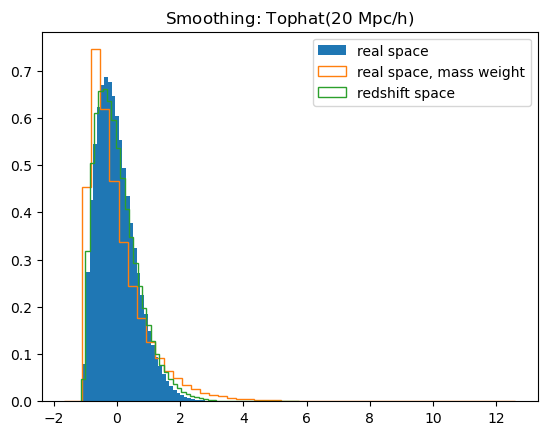

In [6]:
# read counting
counting_real = CountingData(data_path="./output/quijote8000_snap004_counting_sph20.pkl")

plt.hist(counting_real.nx/counting_real.nx.mean()-1, bins=50, density=True, label='real space')
plt.hist(counting_massw.nx/counting_massw.nx.mean()-1, bins=50, density=True, histtype="step", label='real space, mass weight')
plt.hist(counting_rsd.nx/counting_rsd.nx.mean()-1, bins=50, density=True, histtype="step", label='redshift space')
plt.legend()
plt.title(r"Smoothing: Tophat(20 $\rm{Mpc}/h$)")
plt.show()

## 3. Low-level view: sample the smoothed field directly

The final cell bypasses the high-level task wrapper and works with the field objects directly:

- draw random positions in the box
- build a window for each smoothing radius
- evaluate the smoothed field at those points
- compare the resulting PDFs

This is the clearest place to see the underlying principle of `Counting`: it is a random-point probe of a field, not a separate estimator with different physics.


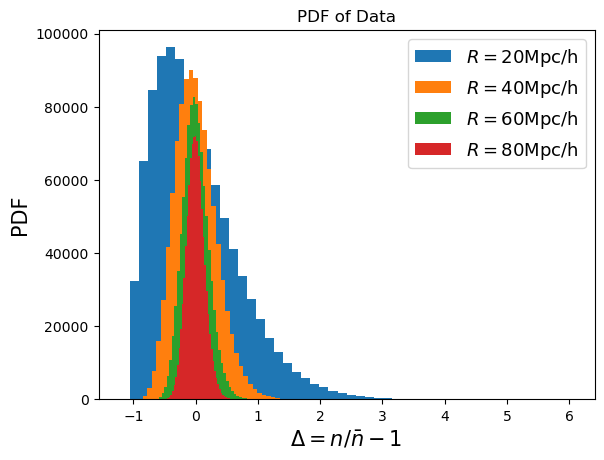

In [7]:
rand = random_points_box(10**6, D.box_size)
win_params = dict(type="sphere", len_args={})
for smooth_radius in [20, 40, 60, 80]:
    win_params["len_args"]["R"] = smooth_radius
    filter = WindowFunc(win_params, D.convols_info, threads=8)
    # n = D.n_at_pos(rand, filter=filter)
    n = (D @ filter).n_at_pos(rand)
    plt.hist(n/n.mean()-1, bins=50, density=False, label=rf'$R={smooth_radius}$Mpc/h')

plt.title('PDF of Data')
plt.xlabel(r'$\Delta=n/{\bar n}-1$', fontsize=15)
plt.ylabel('PDF', fontsize=15)
plt.legend(fontsize=13)
plt.show()